# Transformer based model
This notebooks focuses on building a transformer-based sequential model that captures the song transitions. </br>
The baseline model used is SASRec, because:
- it provide a left-to-right attention mechanism, preserving the order of the input
- the inference process is simple and fast, compared with other models like BERT

### Setups and imports

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import torch
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Data preparation
Importing datasets and vocabularies

In [5]:
#DATA_DIR = "datasets/processed"
DATA_DIR = "/content/drive/MyDrive/recommender_system_DL/processed"

# datasets
with open(f"{DATA_DIR}/train/session_train.pkl", "rb") as f:
    train_data = pickle.load(f)
    train_sessions = [
        track_ids
        for track_ids in train_data["track_key"]
    ]

with open(f"{DATA_DIR}/val/session_val.pkl", "rb") as f:
    val_data = pickle.load(f)
    val_sessions = [
        track_ids
        for track_ids in val_data["track_key"]
    ]

with open(f"{DATA_DIR}/test/session_test.pkl", "rb") as f:    
    test_data = pickle.load(f)
    test_sessions = [
        track_ids
        for track_ids in test_data["track_key"]
    ]

# vocabs
with open(f"{DATA_DIR}/artist_vocab.pkl", "rb") as f:
    artist_vocabs = pickle.load(f)
    artist2idx = artist_vocabs["artist2idx"]
    idx2artist = artist_vocabs["idx2artist"]

with open(f"{DATA_DIR}/track_vocab.pkl", "rb") as f:
    track_vocabs = pickle.load(f)
    track2idx = track_vocabs["track2idx"]
    idx2track = track_vocabs["idx2track"]

In [6]:
print(f"Number of training sessions: {len(train_sessions)}")
print(f"Number of validation sessions: {len(val_sessions)}")
print(f"Number of test sessions: {len(test_sessions)}")
print(f"Number of unique artists: {len(artist2idx)}")
print(f"Number of unique tracks: {len(track2idx)}")

print(f"Example training session: {train_sessions[0]}")

Number of training sessions: 547940
Number of validation sessions: 980
Number of test sessions: 987
Number of unique artists: 269618
Number of unique tracks: 961604
Example training session: [13069633, 12523960, 11373798, 14448993, 1170179, 7954479, 3402063, 9468653, 1847754, 9544038, 10606363, 5081821, 7244365, 8735938, 14823394, 5472971, 15872557, 632090, 13877025, 1848764, 3347068, 461382, 13118687, 3738712, 14388583, 15612679, 13861443, 9843699, 16446568, 16093656, 15872557, 16567215, 9630785, 10912398, 4058991, 3368429, 2905132, 15966390, 13709683, 8585255, 10324680, 15872557, 1040743, 7691923, 184017]


Plotting the duration of each session to find the optimal length to clip

In [7]:
def print_length_distribution(sessions):
    lengths = [len(session) for session in sessions]

    plt.figure(figsize=(8, 5))
    plt.hist(lengths, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title("Session Length Distribution")
    plt.xlabel("Session Length")
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

Average session length: 16.80
Median session length: 13.0
Minimum session length: 5
Maximum session length: 50


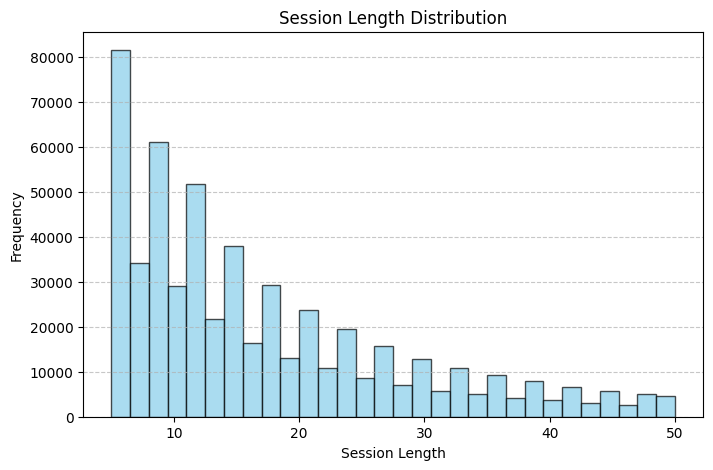

In [8]:
training_session_lengths = [len(session) for session in train_sessions]

print(f"Average session length: {np.mean(training_session_lengths):.2f}")
print(f"Median session length: {np.median(training_session_lengths)}")
print(f"Minimum session length: {np.min(training_session_lengths)}")
print(f"Maximum session length: {np.max(training_session_lengths)}")

print_length_distribution(train_sessions)

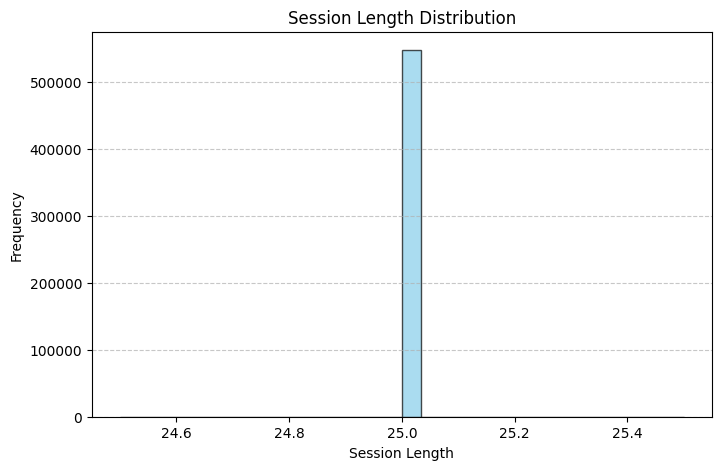

In [9]:
L = 25 # max session length
def pad_or_truncate_sessions(sessions, L):
    for i in range(len(sessions)):
        session = sessions[i]
        if len(session) > L:
            session = session[:L]
        else:
            padding_length = L - len(session)
            session = session + [0] * padding_length
        sessions[i] = session
    return np.array(sessions)


train_sessions_np = pad_or_truncate_sessions(train_sessions, L)
val_sessions_np = pad_or_truncate_sessions(val_sessions, L)
test_sessions_np = pad_or_truncate_sessions(test_sessions, L)

padding_mask = (train_sessions_np == 0) # padding mask

print_length_distribution(train_sessions_np)

### SASRec Model

In [10]:
class SASRec(nn.Module):
    def __init__(self, n_items, d, L):
        super().__init__()
        # embedding blocks
        self.item_emb = nn.Embedding(n_items + 1, d, padding_idx=0).to(device)
        self.pos_emb  = nn.Embedding(L, d).to(device)
        # attention blocks
        self.attention = nn.MultiheadAttention(d, num_heads=2, batch_first=True)
        self.norm = nn.LayerNorm(d)
        self.dropout = nn.Dropout(0.2)
        # feedforward blocks
        self.ff = nn.Sequential(
            nn.Linear(d, d * 4),
            nn.GELU(),
            nn.Linear(d * 4, d),
            nn.Dropout(0.2)
        )
        self.norm2 = nn.LayerNorm(d)

    def forward(self, seq):
        B, L = seq.shape
        positions = torch.arange(L, device=seq.device)
        positions = positions.unsqueeze(0).expand(B, -1)
        x = self.item_emb(seq) + self.pos_emb(positions)

        causal_mask = torch.triu(torch.ones(L, L, device=seq.device), diagonal=1).bool()
        padding_mask = (seq == 0)
        attn_out, _ = self.attention(x, x, x, 
                                     attn_mask=causal_mask, key_padding_mask=padding_mask)
        x = self.norm(x + self.dropout(attn_out))
        x = self.norm2(x + self.ff(x))
        h = x[:, -1, :]
        scores = h @ self.item_emb.weight.T
        return scores

n_items = max(track2idx.values())
d = 128
L = len(train_sessions_np[0])-1

print(f"n_items: {n_items}")
print(f"L: {L}")
print(f"Embedding size: {n_items * d * 4 / 1e6:.1f} MB")

#model = SASRec(n_items, d, L)

n_items: 16982097
L: 24
Embedding size: 8694.8 MB


### Dataset

In [ ]:
class SessionDataset(Dataset):
    def __init__(self, matrix):
        self.matrix = torch.tensor(matrix, dtype=torch.long)

    def __len__(self):
        return len(self.matrix)

    def __getitem__(self, idx):
        seq = self.matrix[idx]
        return seq[:-1], seq[-1]   # input, target

train_dataset = SessionDataset(train_sessions_np)
train_loader  = DataLoader(train_dataset, batch_size=256, shuffle=True)

val_dataset = SessionDataset(val_sessions_np)
val_loader  = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [ ]:
seq, target = next(iter(train_loader))
seq, target = next(iter(val_loader))
print(seq.shape)     # (64, L-1)
print(target.shape)  # (64,)

torch.Size([22, 24])
torch.Size([22])


### Training loop

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
checkpoint = torch.load('sasrec_checkpoint.pt')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch']  # 20

In [25]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
model = model.to(device)
best_val_loss = float('inf')

for epoch in range(start_epoch, 50):
    model.train()
    total_loss = 0

    for seq, target in train_loader:
        seq    = seq.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        scores = model(seq)          # (B, n_items+1)
        loss   = criterion(scores, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for seq, target in val_loader:
            seq, target = seq.to(device), target.to(device)
            scores = model(seq)
            val_loss += criterion(scores, target).item()

    print(f"epoch {epoch+1} — loss: {total_loss / len(train_loader):.4f}, val_loss: {val_loss / len(val_loader):.4f}")

    if val_loss / len(val_loader) < best_val_loss:
        best_val_loss = val_loss / len(val_loader)
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_val_loss,
        }, 'sasrec_best.pt')
        print(f"  ↑ best model saved")

epoch 21 — loss: 12.4117, val_loss: 17.9284
  ↑ best model saved
epoch 22 — loss: 11.9937, val_loss: 17.1926
  ↑ best model saved
epoch 23 — loss: 11.6504, val_loss: 17.2195
epoch 24 — loss: 11.2274, val_loss: 16.7396
  ↑ best model saved
epoch 25 — loss: 10.9179, val_loss: 16.0784
  ↑ best model saved
epoch 26 — loss: 10.5831, val_loss: 15.9688
  ↑ best model saved
epoch 27 — loss: 10.2680, val_loss: 16.1163
epoch 28 — loss: 10.0286, val_loss: 16.7678
epoch 29 — loss: 9.8542, val_loss: 15.8472
  ↑ best model saved
epoch 30 — loss: 9.5944, val_loss: 16.1451
epoch 31 — loss: 9.3749, val_loss: 15.4509
  ↑ best model saved
epoch 32 — loss: 9.1636, val_loss: 15.9846
epoch 33 — loss: 8.9313, val_loss: 15.9969
epoch 34 — loss: 8.8040, val_loss: 15.9817
epoch 35 — loss: 8.5836, val_loss: 16.2610
epoch 36 — loss: 8.3587, val_loss: 16.3963
epoch 37 — loss: 8.2408, val_loss: 15.7411
epoch 38 — loss: 8.0366, val_loss: 16.3464
epoch 39 — loss: 7.8467, val_loss: 16.7113
epoch 40 — loss: 7.6428, val